# **Final Project - Numerical Method**

## Faiq Athaya Urumsah
## Raihan Yudhistira Hartawan

In [ ]:
# Load the Drive helper and mount
from google.colab import drive

# This will prompt for authorization.
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# After executing the cell above, Drive
# files will be present in "/content/drive/My Drive/numed".
!ls "/content/drive/My Drive/numed"

cat.jpg


## ***1. Adding Noise***

In this part, we use Gaussian for adding noises to our image sample "cat.jpg"

Original Cat


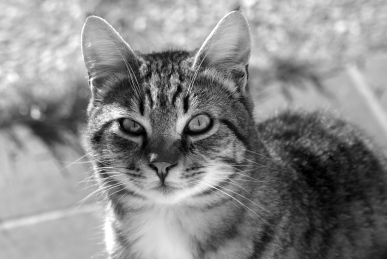

Noisy Image


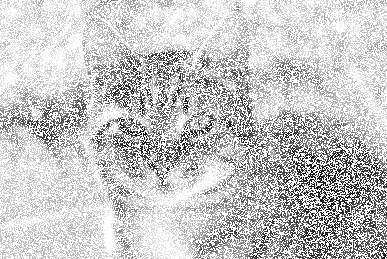

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/drive/My Drive/numed/cat.jpg')

def rescaleFrame(frame, scale=0.4):
    width = int(frame.shape[1] * scale * 0.25)
    height = int(frame.shape[0] * scale * 0.25)
    dimensions = (width, height)

    return cv2.resize(frame, dimensions, interpolation=cv2.INTER_AREA)

def gaussian_noise(img, mean, stddev, gamma = 1):
    #Create Gaussian Noise
    gauss_noise = np.zeros(img.shape[:2])
    cv2.randn(gauss_noise, mean, stddev)
    gauss_noise = (gauss_noise*gamma).astype(np.uint8)

    if len(img.shape) == 2:
        output = cv2.add(img, gauss_noise)
    elif len(img.shape) == 3:
        merged = cv2.merge([gauss_noise, gauss_noise, gauss_noise])
        output = cv2.add(img, merged)
    return gauss_noise, output

resized_image = rescaleFrame(img)

gray = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)

noise, noisy_image = gaussian_noise(gray, mean=0, stddev=25, gamma=1)

print('Original Cat')
cv2_imshow(gray)
print('Noisy Image')
cv2_imshow(noisy_image)


## ***2. Detect Noise***

Noise Map


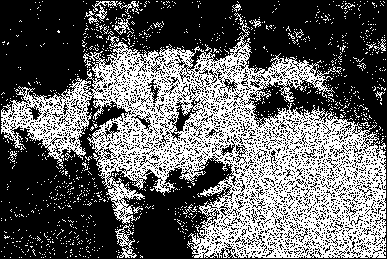

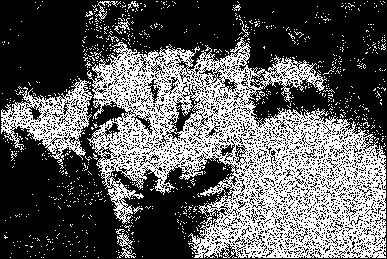

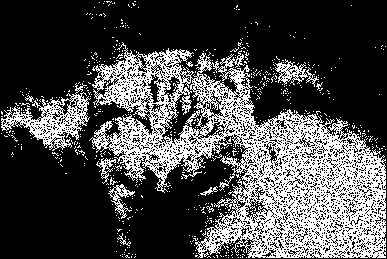

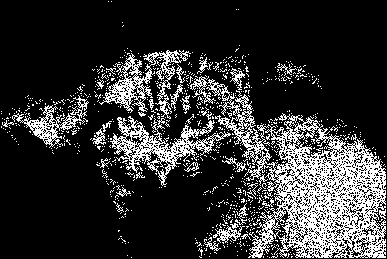

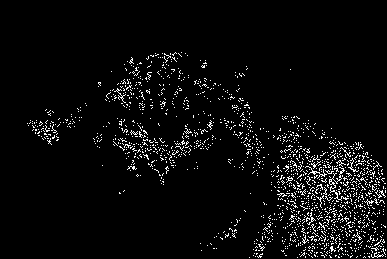

Gradient Magnitude


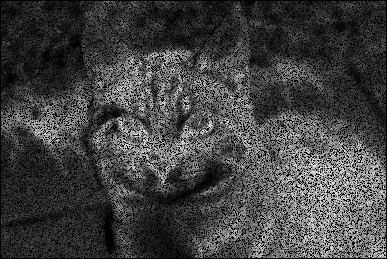

In [ ]:
def finite_difference(noisy_image):
  noisy_image = noisy_image.astype(float)

  Ix = np.zeros_like(noisy_image)
  Iy = np.zeros_like(noisy_image)

  h, w = noisy_image.shape
  for i in range(1, h-1):
    for j in range(1, w-1):
      Ix[i, j] = (noisy_image[i, j+1] - noisy_image[i, j-1]) / 2
      Iy[i, j] = (noisy_image[i+1, j] - noisy_image[i-1, j]) / 2

  return Ix, Iy

Ix, Iy = finite_difference(noisy_image)

#Rate of change
gradient_magnitude = np.sqrt(Ix**2 + Iy**2)

#Threshold
def threshold(gradient_magnitude, k):
  mean = np.average(gradient_magnitude)
  std_deviation = np.std(gradient_magnitude)

  # k is noise sensitivity
  threshold = mean + k*std_deviation
  noise_map = gradient_magnitude > threshold

  return noise_map.astype(np.uint8) * 255

#Noise map
noise_map_001 = threshold(gradient_magnitude, 0.001) #k is 0.001 (very small)
noise_map_01 = threshold(gradient_magnitude, 0.1) #k is 0.1 (very small)
noise_map_05 = threshold(gradient_magnitude, 0.5) #k is 0.5 (small)
noise_map_1 = threshold(gradient_magnitude, 1) #k is 1 (balanced)
noise_map_2 = threshold(gradient_magnitude, 2) #k is 2 (sensitive)

print('Noise Map')
cv2_imshow(noise_map_001)
cv2_imshow(noise_map_01)
cv2_imshow(noise_map_05)
cv2_imshow(noise_map_1)
cv2_imshow(noise_map_2)

print('Gradient Magnitude')
cv2_imshow(gradient_magnitude / gradient_magnitude.max() * 255)

## ***3. Removing Noise***

Gradient descent is used to reduce noise by iteratively updating each noisy pixel toward the average of its neighboring pixels.

The update moves the pixel in the direction that minimizes the difference between it and its neighbors, reducing local intensity variation.

After many iterations, the image becomes smoother while only the detected noisy pixels are modified.

Iteration 1 done
Iteration 2 done
Iteration 3 done
Iteration 4 done
Iteration 5 done
Iteration 6 done
Iteration 7 done
Iteration 8 done
Iteration 9 done
Iteration 10 done
Noisy Image


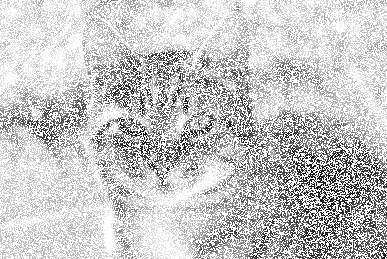

Denoised Image


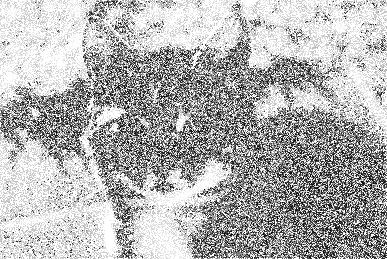

Original Cat


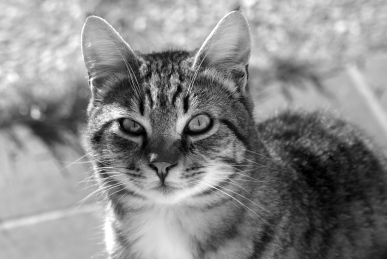

In [ ]:
def gradient_descent(noisy_image, noise_map, learning_rate, iterations):
    X = noisy_image.astype(float)

    h,w = X.shape

    for k in range(iterations):
      X_new = X.copy()
      for i in range(1, h-1):
        for j in range(1, w-1):
          if noise_map[i, j] == 0:
            continue

          mu = (X[i+1, j] + X[i-1, j] + X[i, j+1] + X[i, j-1]) / 4
          gradient = (mu - X[i, j])

          X_new[i, j] = X[i, j] - learning_rate * gradient

      X = X_new

      print(f"Iteration {k+1} done")

    return X

noise_map = threshold(gradient_magnitude, 0.001)

denoised = gradient_descent(noisy_image, noise_map, learning_rate=0.1, iterations=10)

print('Noisy Image')
cv2_imshow(noisy_image)
print('Denoised Image')
cv2_imshow(denoised.astype(np.uint8))
print('Original Cat')
cv2_imshow(gray)

## ***4. Quality Metrics***

We use 2 indicators:
- PSNR (Peak Signal to Noise Ratio)
- SSIM (Structural Similarity Index Measure)

In [ ]:
from skimage.metrics import peak_signal_noise_ratio as psnr

original = gray.astype(np.uint8)
noisy = noisy_image.astype(np.uint8)
denoised_img = denoised.astype(np.uint8)

print("QUALITY METRICS")

print("\nNoisy vs Original")
print("PSNR:", psnr(original, noisy, data_range=255))

print("\nDenoised vs Original")
print("PSNR:", psnr(original, denoised_img, data_range=255))

QUALITY METRICS

Noisy vs Original
PSNR: 8.76566105869416

Denoised vs Original
PSNR: 10.03492572963708


References:

*   https://medium.com/@muyandiritujr/noise-in-image-processing-and-how-to-add-it-to-images-in-python-456a434dcc3f
*   https://www.geeksforgeeks.org/machine-learning/how-to-implement-a-gradient-descent-in-python-to-find-a-local-minimum/

